In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
with open('data_sps_4D.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['x', 'px', 'y', 'py'])

In [4]:
data['x'].shape, data['px'].shape, data['y'].shape, data['py'].shape

((10000, 1000), (10000, 1000), (10000, 1000), (10000, 1000))

Text(0, 0.5, '$p_x$')

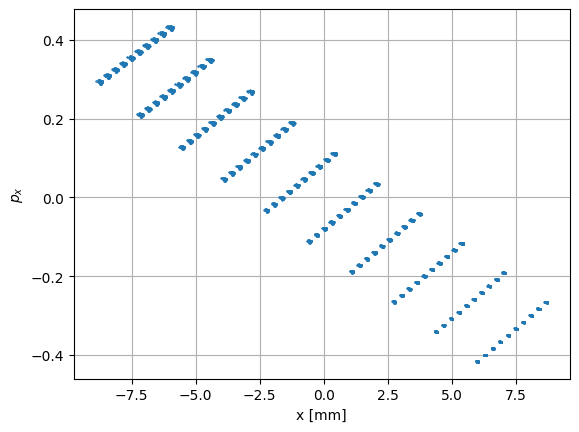

In [5]:
plt.plot(data['x'][:, 1] * 1000, data['px'][:, 1] * 1000, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [6]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from models import GSympNet

In [7]:
# Hyperparameters
dim = 4
layers = 9
width = 20
activation = torch.sigmoid
epochs = 100
batch_size = 64
learning_rate = 1e-3

In [8]:
# # x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(data['x'].shape[0])]
# x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(700)]
# x_xp_data = np.vstack(x_xp_data_list)

In [9]:
def min_max_normalize(arr, min_val=None, max_val=None):
    """
    Min-max normalize a numpy array or torch tensor of shape (N, 2) to range [-1, 1].
    If min_val and max_val are not provided, compute from arr along axis=0.
    Returns normalized array, min_val, and max_val.
    """
    if min_val is None:
        min_val = arr.min(axis=0, keepdims=True)
    if max_val is None:
        max_val = arr.max(axis=0, keepdims=True)
    normalized = 2 * (arr - min_val) / (max_val - min_val) - 1
    return normalized, min_val, max_val

def min_max_denormalize(arr, min_val, max_val):
    """
    Denormalize a numpy array or torch tensor of shape (N, 2) from range [-1, 1]
    back to the original range defined by min_val and max_val.
    """
    return (arr + 1) / 2 * (max_val - min_val) + min_val

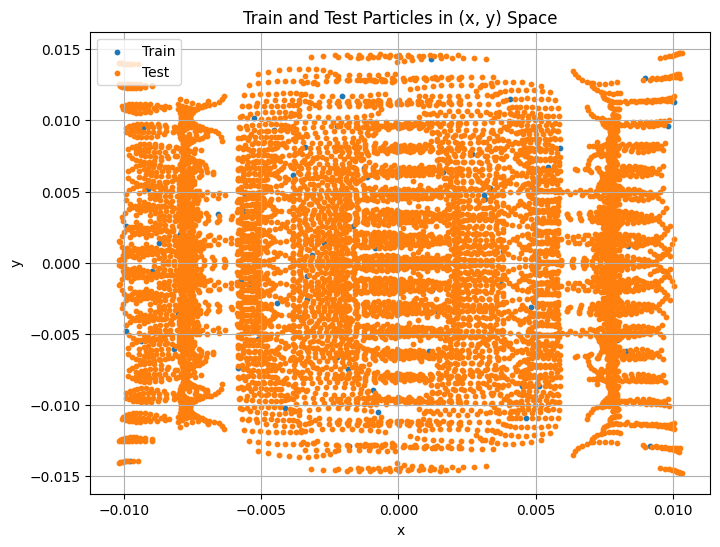

In [10]:
np.random.seed(42)  # For reproducibility

num_particles = data['x'].shape[0]
train_size = 100

# Randomly select indices for training particles
train_indices = np.random.choice(num_particles, size=train_size, replace=False)

# remaining indices are used for testing
test_indices = np.setdiff1d(np.arange(num_particles), train_indices)

# indices to select train particles
x_train = data['x'][train_indices, :]
px_train = data['px'][train_indices, :]
y_train = data['y'][train_indices, :]
py_train = data['py'][train_indices, :]

x_test = data['x'][test_indices, :]
px_test = data['px'][test_indices, :]
y_test = data['y'][test_indices, :]
py_test = data['py'][test_indices, :]

# Plot the train and test particles in (x, px) space
plt.figure(figsize=(8,6))
plt.scatter(x_train[:, 100], y_train[:, 100], s=10, color='C0', label='Train')
plt.scatter(x_test[:, 100], y_test[:, 100], s=10, color='C1', label='Test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Train and Test Particles in (x, y) Space')
plt.legend()
plt.grid()
plt.show()

In [11]:
data['x'].shape, data['y'].shape, data['px'].shape, data['py'].shape

((10000, 1000), (10000, 1000), (10000, 1000), (10000, 1000))

In [12]:
x_train.shape, px_train.shape, x_test.shape, px_test.shape, y_train.shape, py_train.shape, y_test.shape, py_test.shape

((100, 1000),
 (100, 1000),
 (9900, 1000),
 (9900, 1000),
 (100, 1000),
 (100, 1000),
 (9900, 1000),
 (9900, 1000))

In [13]:
num_turns = 1000
train_data_list = [np.array([x_train[i, :num_turns], y_train[i, :num_turns], px_train[i, :num_turns], py_train[i, :num_turns]]).T for i in range(x_train.shape[0])]
train_data = np.vstack(train_data_list)

In [14]:
train_norm, min, max = min_max_normalize(train_data)

In [15]:
input, output = train_norm[:-1], train_norm[1:]

In [16]:
input-output

array([[ 0.48726541, -0.03873205, -0.39926553, -0.78682207],
       [-0.09067245,  0.40826228,  0.6221672 ,  0.66864466],
       [-0.35443739, -0.68102432, -0.51326067, -0.38608549],
       ...,
       [ 0.89551737,  0.99042466,  0.46557638, -0.65790401],
       [-0.98538099, -0.54544512,  0.27896067,  1.03455995],
       [ 0.54319735,  0.01326176, -0.87408495, -1.17652151]],
      shape=(99999, 4))

In [17]:
train_x = torch.tensor(input, dtype=torch.float32)
train_y = torch.tensor(output, dtype=torch.float32)

In [18]:
train_x.shape

torch.Size([99999, 4])

In [19]:
dataset = TensorDataset(train_x, train_y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [20]:
model = GSympNet(dim, layers, width, activation)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

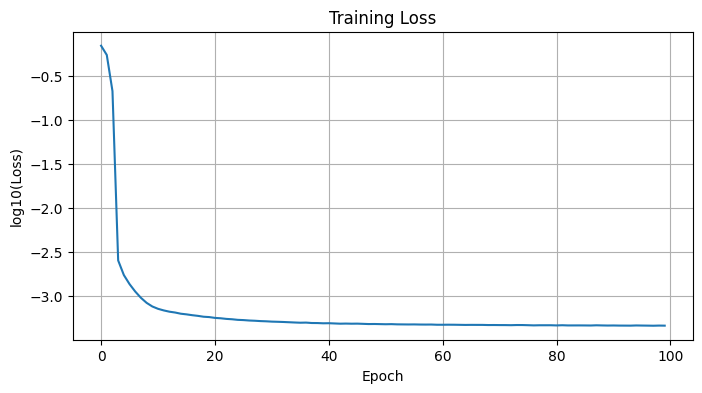

In [21]:
losses = []

model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)
    losses.append(avg_loss)
    # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")
    
    # Real-time plot
    if (epoch+1) % 1 == 0 or epoch == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8,4))
        # plt.plot(losses)
        # plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.plot(np.log10(losses))
        plt.ylabel('log10(Loss)')
        plt.title('Training Loss')
        plt.grid()
        plt.show()

In [22]:
torch.save(model.state_dict(),'sympnet_model_multiparticle_xy1.pt')

In [21]:
# Re-instantiate the model and load the saved weights
model = GSympNet(dim, layers, width, activation)
model.load_state_dict(torch.load('sympnet_model_multiparticle_xy1.pt'))

<All keys matched successfully>

In [22]:
init_test = np.array([x_test[:100, 0], y_test[:100,0], px_test[:100, 0], py_test[:100,0]]).T

In [23]:
# x_xp_init_test = np.array([data['x'][index, 700], data['px'][index, 700]]).T

In [24]:
# x_xp_init_test = x_xp_init_test.reshape(1, 2)
init_test.shape, init_test.dtype

((100, 4), dtype('float64'))

In [25]:
min.dtype

dtype('float64')

In [26]:
init_test_norm = min_max_normalize(init_test, min, max)[0]

In [27]:
init_test_tensor = torch.tensor(init_test_norm, dtype=torch.float32)

In [28]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
init_test_tensor.shape

torch.Size([100, 4])

In [29]:
pred_init = model.predict(init_test_tensor, steps=999)

In [30]:
x_test.shape

(9900, 1000)

In [31]:
test = np.array([x_test[:100, 1:], y_test[:100, 1:], px_test[:100, 1:], py_test[:100, 1:]]).T

In [32]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [33]:
test.shape, pred.shape

((999, 100, 4), (100, 999, 4))

Text(0, 0.5, '$p_x$')

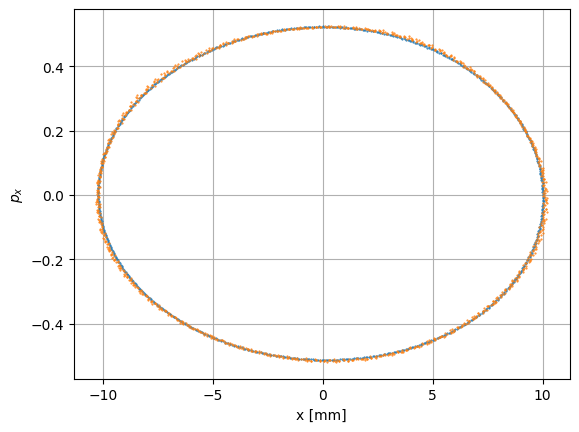

In [34]:
index = 50
plt.plot(test[:, index, 0] * 1000, test[:, index, 2] * 1000, '.', markersize=1, color='C0')
plt.plot(pred[index, :, 0] * 1000, pred[index, :, 2] * 1000, '.', markersize=1, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

Text(0, 0.5, '$p_y$')

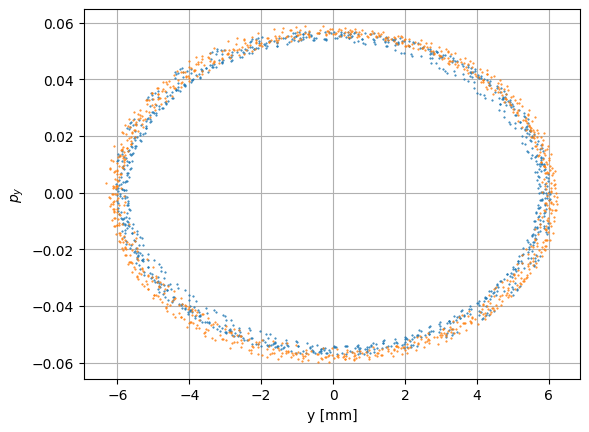

In [35]:
plt.plot(test[:, index, 1] * 1000, test[:, index, 3] * 1000, '.', markersize=1, color='C0')
plt.plot(pred[index, :, 1] * 1000, pred[index, :, 3] * 1000, '.', markersize=1, color='C1')
plt.grid()
plt.xlabel('y [mm]')
plt.ylabel(r'$p_y$')

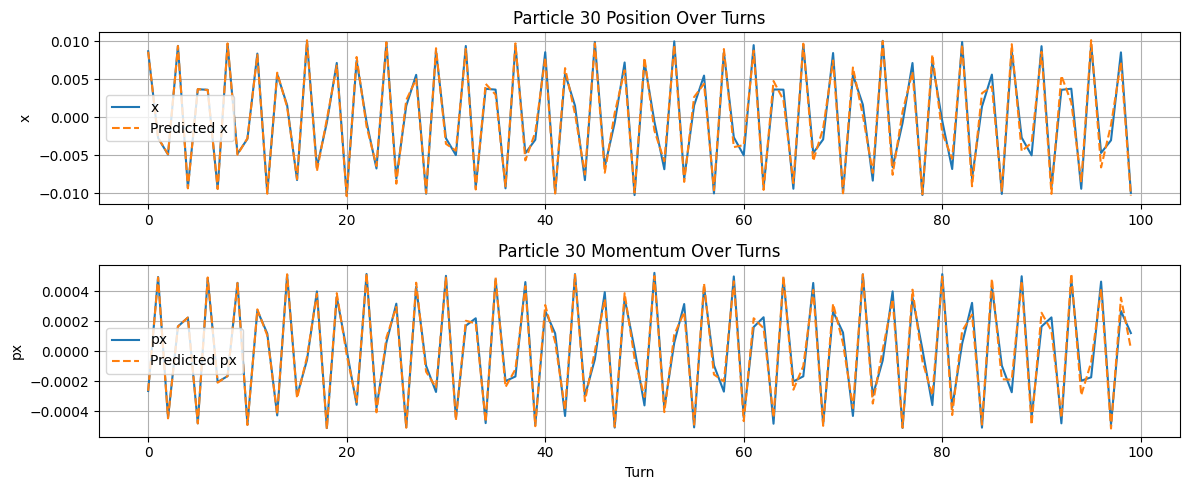

In [36]:
# Plot position and momentum over turns

index = 30  # Change this to visualize different particles

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(test[:100, index, 0], label='x', color='C0')
plt.plot(pred[index, :100, 0].squeeze(), label='Predicted x', linestyle='--', color='C1')
plt.title(f'Particle {index} Position Over Turns')
plt.ylabel('x')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(test[:100, index, 2], label='px', color='C0')
plt.plot(pred[index, :100, 2].squeeze(), label='Predicted px', linestyle='--', color='C1')
plt.title(f'Particle {index} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('px')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

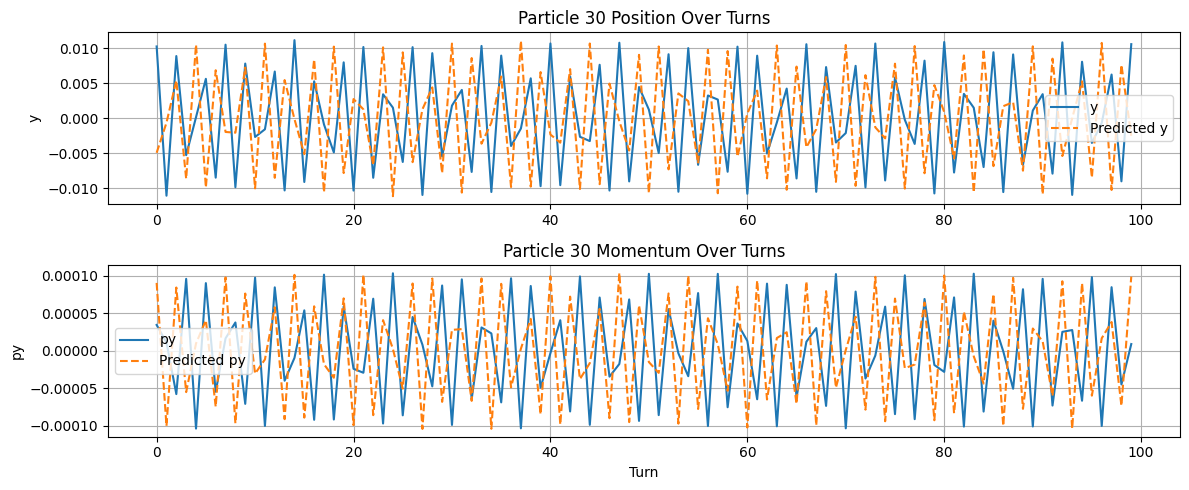

In [37]:
# Plot position and momentum over turns

index = 30  # Change this to visualize different particles

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(test[-100:, index, 1], label='y', color='C0')
plt.plot(pred[index, -100:, 1].squeeze(), label='Predicted y', linestyle='--', color='C1')
plt.title(f'Particle {index} Position Over Turns')
plt.ylabel('y')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(test[-100:, index, 3], label='py', color='C0')
plt.plot(pred[index, -100:, 3].squeeze(), label='Predicted py', linestyle='--', color='C1')
plt.title(f'Particle {index} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('py')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

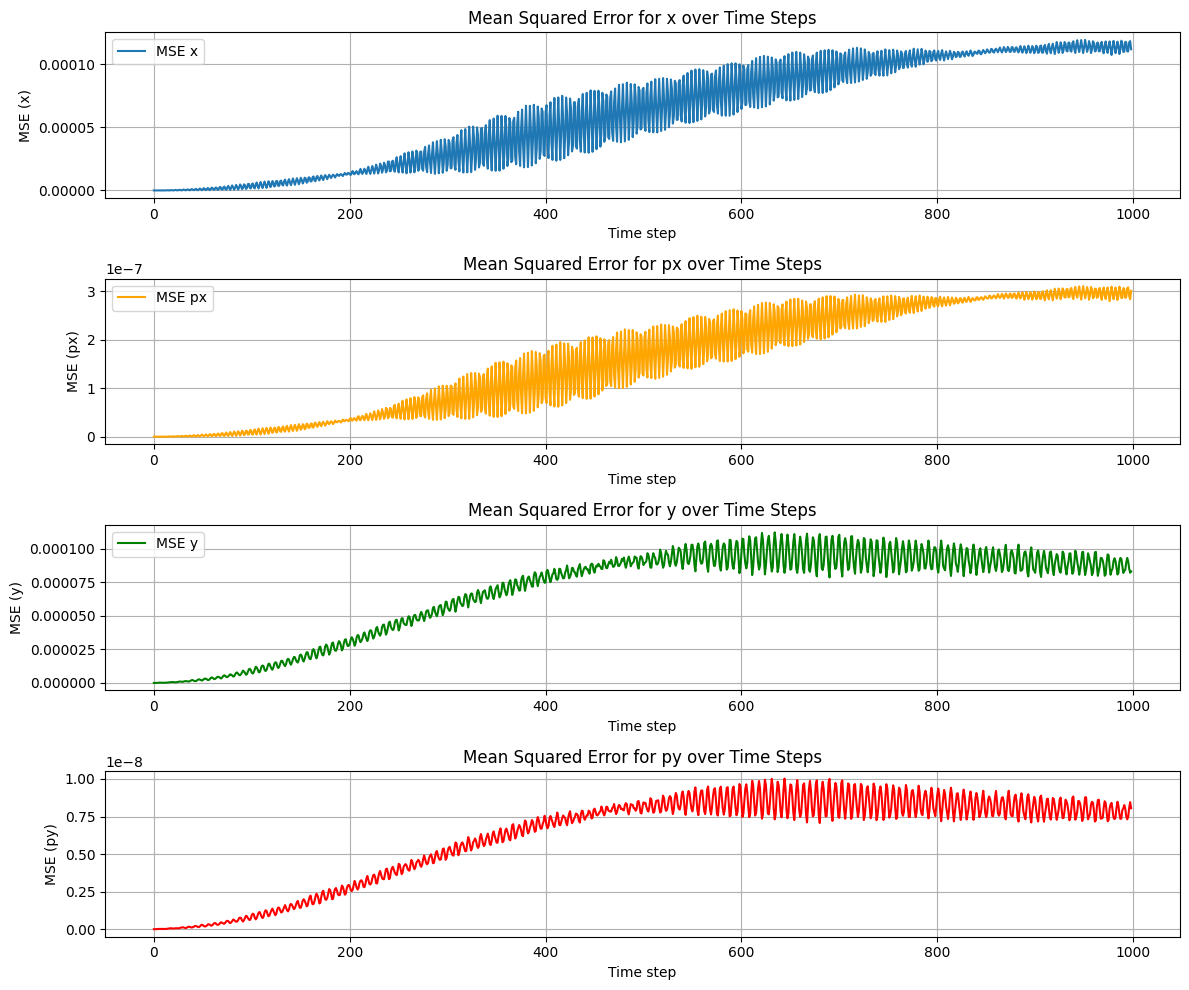

In [38]:
# pred: shape (num_particles, num_timesteps, 2)
# x_xp_test: shape (num_timesteps, num_particles, 2)
# Let's transpose x_xp_test to (num_particles, num_timesteps, 2) for comparison
x_xp_test_aligned = np.transpose(test, (1, 0, 2))

# Compute MSE at each time step for x and px separately
mse_x = np.mean((pred[:, :, 0] - x_xp_test_aligned[:, :, 0]) ** 2, axis=0)
mse_px = np.mean((pred[:, :, 2] - x_xp_test_aligned[:, :, 2]) ** 2, axis=0)
mse_y = np.mean((pred[:, :, 1] - x_xp_test_aligned[:, :, 1]) ** 2, axis=0)
mse_py = np.mean((pred[:, :, 3] - x_xp_test_aligned[:, :, 3]) ** 2, axis=0)

# Plot both on subplots
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(mse_x, label='MSE x')
plt.xlabel('Time step')
plt.ylabel('MSE (x)')
plt.title('Mean Squared Error for x over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(mse_px, label='MSE px', color='orange')
plt.xlabel('Time step')
plt.ylabel('MSE (px)')
plt.title('Mean Squared Error for px over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(mse_y, label='MSE y', color='green')
plt.xlabel('Time step')
plt.ylabel('MSE (y)')
plt.title('Mean Squared Error for y over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(mse_py, label='MSE py', color='red')
plt.xlabel('Time step')
plt.ylabel('MSE (py)')
plt.title('Mean Squared Error for py over Time Steps')
plt.grid()

plt.tight_layout()
plt.show()

In [41]:
import PyNAFF as pnf

In [62]:
# x
print(pnf.naff(test[:500, index, 0], turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(test[500:, index, 0], turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, :500, 0].squeeze(), turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, 500:, 0].squeeze(), turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))


[[ 0.          0.37928894  0.0050545   0.00433586 -0.00259774]]
[[ 0.          0.37928892  0.00505452 -0.00471605 -0.00181855]]
[[ 0.          0.3796127   0.00502512  0.00433048 -0.00254927]]
[[ 0.          0.37961265  0.00502584 -0.00089027 -0.00494636]]


In [63]:
# y
print(pnf.naff(test[:500, index, 3], turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(test[500:, index, 3], turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, :500, 3].squeeze(), turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, 500:, 3].squeeze(), turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))


[[ 0.00000000e+00  4.23730903e-01  5.12635242e-05  3.54378749e-05
  -3.70419483e-05]]
[[ 0.00000000e+00  4.23730894e-01  5.12635375e-05 -4.20477282e-06
  -5.10908032e-05]]
[[ 0.00000000e+00  4.24016116e-01  5.09577421e-05  3.67194340e-05
  -3.53323456e-05]]
[[ 0.00000000e+00  4.24016645e-01  5.09769266e-05  3.84644812e-05
  -3.34534114e-05]]
